# ROAD SEGMENTATION

In [ ]:
'''
Fragment to try on : 
# 11545_sat
# 14361_sat
# 4227_sat
# 5279_sat
# 17193_sat

 Classical road segmentation on aerial map.

    Pipeline:
      1. CLAHE on L(lightness) channel (LAB) — normalize lighting , improve contrast 
      2. HSV threshold — roads: low saturation, mid brightness (gray-ish)
      3. Morphological close — fill gaps in road interiors
      4. Morphological open  — remove small noise blobs
      5. Contour filter — keep only large or elongated regions


      
CLAHE (Contrast Limited Adaptive Histogram Equalization)  - works by dividing img to smaller 
& adjust contrast in each part, helps in avoiding too bright or too dark
    parameters : Cliplimit ( threshold for contrast limiting : default - 40)
    titleGridSize : sets no of rows and columns ( deafaul t; 8 * 8)

LAB - Lightness [0-255], (Green -Red)[+ve : R, -ve: G] , (Blue-Yellow)[+ve : Y, -ve: B]
Need of LAB ??
'''




In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("DeepGlobe_Dataset/train/11545_sat.jpg")

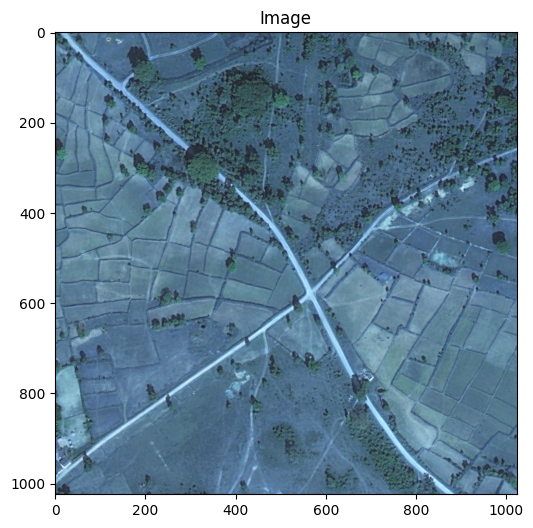

In [4]:
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Image")
plt.show()

In [5]:
# CLAHE equalisation
lab      = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b  = cv2.split(lab)
clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
l_eq     = clahe.apply(l)
img_eq   = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)



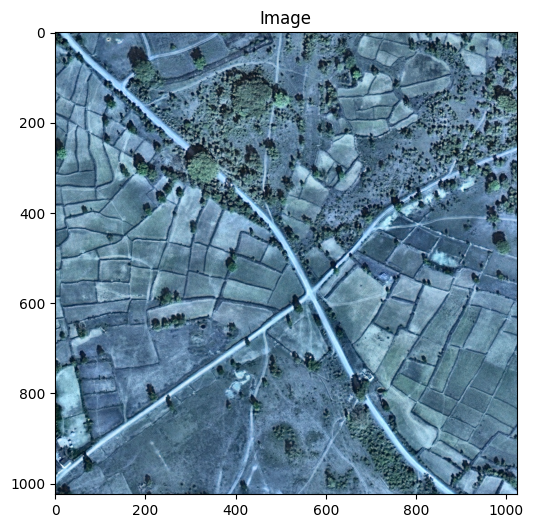

In [6]:
plt.figure(figsize=(10, 6))
plt.imshow(img_eq)
plt.title("Image")
plt.show()

In [7]:
# HSV Threshold 
hsv = cv2.cvtColor(img_eq, cv2.COLOR_BGR2HSV)
lower = np.array([7,97, 193 ]) #ROAD_VAL_MIN])
upper = np.array([89, 255, 255]) #ROAD_SAT_MAX, ROAD_VAL_MAX])
mask = cv2.inRange(hsv, lower, upper)

In [26]:
# use slider detect hsv lower and upper 

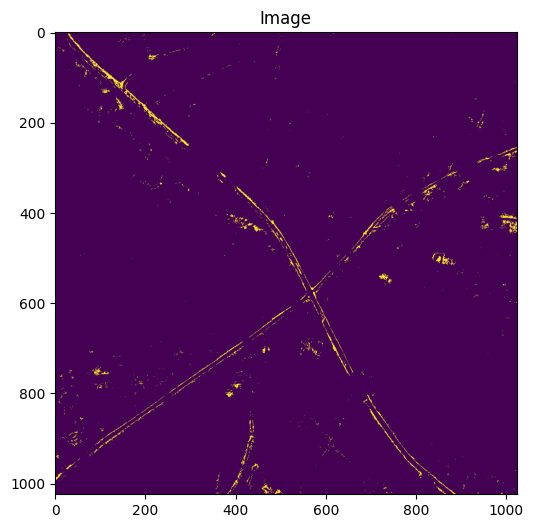

In [8]:
plt.figure(figsize=(10, 6))
plt.imshow(mask)
plt.title("Image")
plt.show()

In [9]:
# bridge/close small gaps 
k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=2)

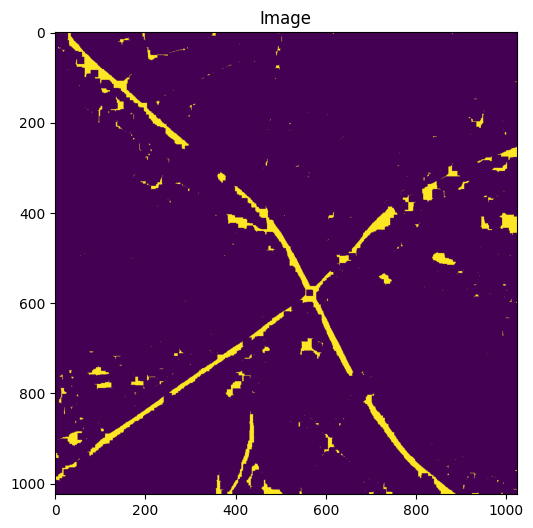

In [10]:
plt.figure(figsize=(10, 6))
plt.imshow(mask)
plt.title("Image")
plt.show()

In [11]:
# remove noise 
k_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open, iterations=1)

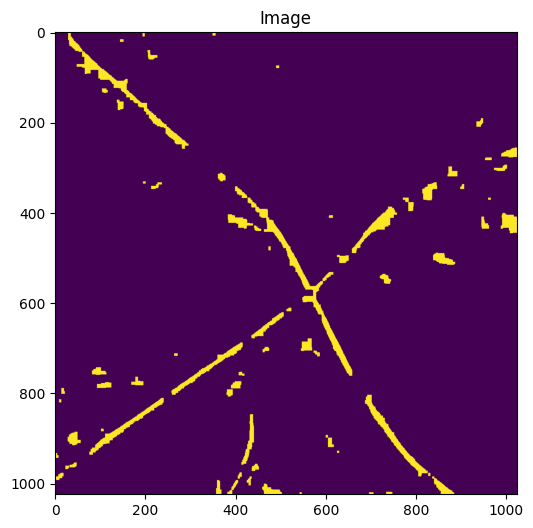

In [12]:
plt.figure(figsize=(10, 6))
plt.imshow(mask)
plt.title("Image")
plt.show()

In [ ]:
# contour  filter - keep large or enlongated shapes
